In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../src")
from database import engine

In [2]:
query = """
SELECT
    d.timestamp,
    d.ontario_demand,

    MAX(CASE
        WHEN w.station = 'toronto'
        THEN w.temperature
    END) AS toronto_temp,

    MAX(CASE
        WHEN w.station = 'ottawa'
        THEN w.temperature
    END) AS ottawa_temp,

    MAX(CASE
        WHEN w.station = 'windsor'
        THEN w.temperature
    END) AS windsor_temp,

    MAX(CASE
        WHEN w.station = 'sudbury'
        THEN w.temperature
    END) AS sudbury_temp,

    MAX(CASE
        WHEN w.station = 'thunder_bay'
        THEN w.temperature
    END) AS thunder_bay_temp

FROM demand_hourly d

JOIN weather_hourly w
    ON d.timestamp = w.timestamp

GROUP BY
    d.timestamp,
    d.ontario_demand

ORDER BY d.timestamp;
"""

df = pd.read_sql(query, engine)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,ontario_demand,toronto_temp,ottawa_temp,windsor_temp,sudbury_temp,thunder_bay_temp
0,2025-01-01 00:00:00,13887,1.6,1.5,1.0,-1.2,-4.0
1,2025-01-01 01:00:00,13722,1.6,1.8,0.7,-1.4,-4.3
2,2025-01-01 02:00:00,13688,1.4,1.7,0.9,-1.5,-4.4
3,2025-01-01 03:00:00,13613,0.8,1.7,1.2,-1.6,-4.9
4,2025-01-01 04:00:00,13593,1.4,1.8,1.2,-1.7,-5.5


In [5]:
df["hour"] = df["timestamp"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_of_week"] = df["timestamp"].dt.day_name()

existing_day_columns = [
    column for column in df.columns
    if column.startswith("day_") and column != "day_of_week"
]

df = df.drop(
    columns=existing_day_columns,
    errors="ignore"
)

day_columns = pd.get_dummies(
    df["day_of_week"],
    prefix="day",
    dtype=int,
    drop_first=True
)

df = pd.concat(
    [df, day_columns],
    axis=1
)

weather_features = [
    "toronto_temp",
    "ottawa_temp",
    "windsor_temp",
    "sudbury_temp",
    "thunder_bay_temp"
]

df["avg_temp"] = df[weather_features].mean(axis=1)

day_features = day_columns.columns.tolist()

In [7]:
BASE_TEMP = 18

df["heating"] = np.maximum(
    BASE_TEMP - df["avg_temp"],
    0
)

df["cooling"] = np.maximum(
    df["avg_temp"] - BASE_TEMP,
    0
)

df[
    [
        "timestamp",
        "avg_temp",
        "heating",
        "cooling"
    ]
].head(20)

df[
    [
        "avg_temp",
        "heating",
        "cooling"
    ]
].sort_values("avg_temp").head()

,avg_temp,heating,cooling
464,-21.98,39.98,0.0
486,-21.98,39.98,0.0
488,-21.96,39.96,0.0
487,-21.78,39.78,0.0
463,-21.52,39.52,0.0


In [8]:
X = df[
    ["hour_sin", "hour_cos"]
    + day_features
    + weather_features
    + ["heating", "cooling"]
]

y = df["ontario_demand"]

In [9]:
X.columns.tolist()

['hour_sin',
 'hour_cos',
 'day_Monday',
 'day_Saturday',
 'day_Sunday',
 'day_Thursday',
 'day_Tuesday',
 'day_Wednesday',
 'toronto_temp',
 'ottawa_temp',
 'windsor_temp',
 'sudbury_temp',
 'thunder_bay_temp',
 'heating',
 'cooling']

In [10]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-1133.59, -889.26, -66.83,..., 36.46, 383.64, 438.97]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['hour_sin','hour_cos','day_Monday',...,'thunder_bay_temp','heating', 'cooling']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9426
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [12]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 1158800.4156532453
RMSE: 1076.4759243258743


In [24]:
results["abs_error"] = results["residual"].abs()

results.sort_values(
    "abs_error",
    ascending=False
).head(10)

,timestamp,actual,predicted,residual,abs_error
1376,2025-12-16 08:00:00,20106,16738.338352,3367.661648,3367.661648
1279,2025-12-12 07:00:00,19769,16516.446587,3252.553413,3252.553413
1280,2025-12-12 08:00:00,19960,16811.009656,3148.990344,3148.990344
1375,2025-12-16 07:00:00,19580,16448.285448,3131.714552,3131.714552
1338,2025-12-14 18:00:00,21079,18064.806665,3014.193335,3014.193335
1352,2025-12-15 08:00:00,20542,17538.470949,3003.529051,3003.529051
1351,2025-12-15 07:00:00,20130,17129.238921,3000.761079,3000.761079
1339,2025-12-14 19:00:00,20734,17793.913360,2940.086640,2940.086640
1337,2025-12-14 17:00:00,21148,18239.964113,2908.035887,2908.035887
1377,2025-12-16 09:00:00,19948,17100.733851,2847.266149,2847.266149


<Axes: title={'center': 'Average Error by Hour'}, xlabel='hour'>

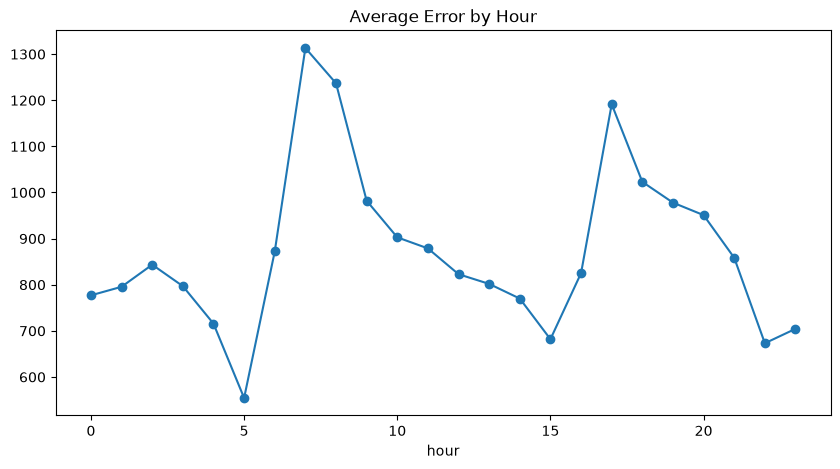

In [25]:
analysis.groupby("hour")["abs_error"].mean().plot(
    marker="o",
    figsize=(10, 5),
    title="Average Error by Hour"
)

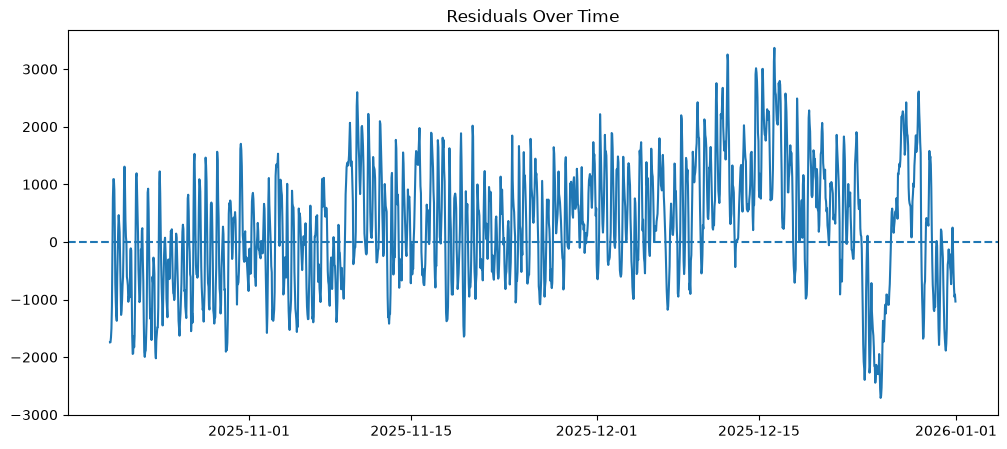

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(results["timestamp"], results["residual"])
plt.axhline(0, linestyle="--")
plt.title("Residuals Over Time")
plt.show()